# Trajectory Analysis — Low-Emission Aircraft Integration into European Airspace

**Author:** Gamar Ismayilova  
**Date:** May 2026  
**Tools:** Python, OpenAP (Sun et al., 2020), Onorato et al. (2022)

## Research question
How do the operational trajectory constraints of hydrogen fuel cell aircraft 
differ from conventional aircraft on European short-haul routes, and what are 
the implications for mixed-fleet climb sector occupancy?

## Key findings
- Hydrogen aircraft burn **65.7% less fuel** per flight (TSFC ratio: 0.357)
- Under kinematic penalty assumptions (Option B), hydrogen aircraft take 
  **1.2 minutes longer** to reach cruise altitude — a 5.3% increase
- At 50% fleet penetration on Amsterdam–London, climb sector accumulates 
  **29.4 extra minutes of occupancy per day**
- The choice between Option A and Option B modelling assumptions 
  fundamentally changes the ATM capacity conclusion

## References
- Sun, J., Hoekstra, J.M., Ellerbroek, J. (2020). OpenAP: An open-source 
  aircraft performance model. *Aerospace*, 7(8), 104.
- Sun, J., Ellerbroek, J., Hoekstra, J.M. (2019). WRAP: An open-source 
  kinematic aircraft performance model. *Transportation Research Part C*, 98, 118–138.
- Onorato, G., Proesmans, P., Hoogreef, M.F.M. (2022). Assessment of hydrogen 
  transport aircraft: Effects of fuel tank integration. *CEAS Aeronautical Journal*, 13, 813–845.
- Schäfer, M. et al. (2014). Bringing up OpenSky. *IPSN*, 83–94.

## Module 1 — Conventional A320 Baseline Trajectory

Using OpenAP FlightGenerator to model a conventional A320 trajectory 
and calculate fuel flow across all flight phases.

**Key result:** Climb duration = 22.2 min | Total fuel = 4865 kg | Distance = 1388 km

In [1]:
from openap import FuelFlow

fuelflow = FuelFlow(ac='A320')
FF = fuelflow.enroute(mass=60000, tas=230, alt=32000)
print(f"Cruise fuel flow: {FF:.3f} kg/s")

hydrogen_scale = 0.5154e-5 / 1.443e-5
FF_h2 = FF * hydrogen_scale
print(f"Hydrogen equivalent: {FF_h2:.3f} kg/s")

Cruise fuel flow: 0.903 kg/s
Hydrogen equivalent: 0.322 kg/s


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from openap.gen import FlightGenerator

# conventional A320 baseline
fgen = FlightGenerator(ac='A320')

# generate complete flight trajectory
flight = fgen.complete(dt=10)

print(flight.head())
print(f"\nColumns: {flight.columns.tolist()}")
print(f"Total duration: {flight.t.max()} seconds ({flight.t.max()/60:.1f} minutes)")
print(f"Total distance: {flight.s.max()/1000:.1f} km")

    t    h       s     v   vs  altitude  vertical_rate  groundspeed
0   0  0.0     0.0   0.0  0.0         0              0            0
1  10  0.0     0.0  19.3  0.0         0              0           37
2  20  0.0   193.0  38.6  0.0         0              0           75
3  30  0.0   579.0  57.9  0.0         0              0          112
4  40  0.0  1158.0  77.2  0.0         0              0          150

Columns: ['t', 'h', 's', 'v', 'vs', 'altitude', 'vertical_rate', 'groundspeed']
Total duration: 6830 seconds (113.8 minutes)
Total distance: 1387.7 km


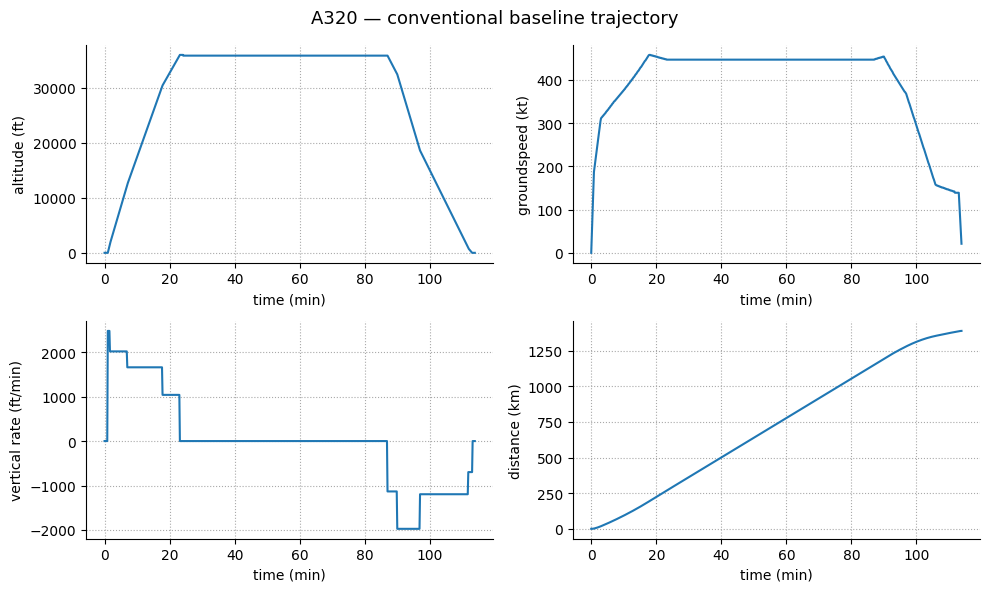

In [23]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 6))

ax1.plot(flight.t / 60, flight.altitude)
ax2.plot(flight.t / 60, flight.groundspeed)
ax3.plot(flight.t / 60, flight.vertical_rate)
ax4.plot(flight.t / 60, flight.s / 1000)

ax1.set_ylabel("altitude (ft)")
ax2.set_ylabel("groundspeed (kt)")
ax3.set_ylabel("vertical rate (ft/min)")
ax4.set_ylabel("distance (km)")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("time (min)")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(linestyle=":", color="darkgray")

plt.suptitle("A320 — conventional baseline trajectory", fontsize=13)
plt.tight_layout()
plt.savefig('figures/02_trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# check units first
print("Sample v values:", flight.v.head(10).tolist())
print("Sample groundspeed values:", flight.groundspeed.head(10).tolist())
print("Max altitude:", flight.altitude.max())

Sample v values: [0.0, 19.3, 38.6, 57.900000000000006, 77.2, 96.5, 101.5, 106.5, 111.5, 116.5]
Sample groundspeed values: [0, 37, 75, 112, 150, 187, 197, 207, 216, 226]
Max altitude: 35934


In [5]:
from openap import FuelFlow
import numpy as np

fuelflow = FuelFlow(ac='A320')

mass_current = 66000
fuel_flow = []

for _, row in flight.iterrows():
    # skip ground phase — fuel model needs airborne conditions
    if row.altitude < 100 or row.groundspeed < 50:
        fuel_flow.append(0.0)
        continue
    
    ff = fuelflow.enroute(
        mass=mass_current,
        tas=float(row.groundspeed),
        alt=float(row.altitude),
        vs=float(row.vertical_rate)
    )
    
    # handle NaN from model
    if np.isnan(ff) or ff < 0:
        ff = 0.0
    
    fuel_flow.append(ff)
    mass_current -= ff * 10

flight['fuel_flow'] = fuel_flow
flight['fuel_burned'] = flight.fuel_flow * 10

total_fuel = flight.fuel_burned.sum()
print(f"Total fuel burned: {total_fuel:.0f} kg")

# check a few values
print("\nSample fuel flow values (airborne only):")
print(flight[flight.altitude > 100].fuel_flow.head(10).round(3).tolist())


Total fuel burned: 4865 kg

Sample fuel flow values (airborne only):
[1.854, 1.825, 1.795, 1.632, 1.611, 1.592, 1.576, 1.563, 1.554, 1.546]


In [6]:
# check how many rows have zero vs non-zero fuel flow
print(f"Total rows: {len(flight)}")
print(f"Rows with fuel_flow > 0: {(flight.fuel_flow > 0).sum()}")
print(f"Rows with fuel_flow == 0: {(flight.fuel_flow == 0).sum()}")
print(f"\nAltitude range of zero-flow rows:")
print(flight[flight.fuel_flow == 0].altitude.describe())
print(f"\nGroundspeed range of zero-flow rows:")
print(flight[flight.fuel_flow == 0].groundspeed.describe())

Total rows: 686
Rows with fuel_flow > 0: 673
Rows with fuel_flow == 0: 13

Altitude range of zero-flow rows:
count    13.000000
mean      0.615385
std       2.218801
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       8.000000
Name: altitude, dtype: float64

Groundspeed range of zero-flow rows:
count     13.000000
mean      95.307692
std       61.954802
min        0.000000
25%       45.000000
50%       92.000000
75%      139.000000
max      197.000000
Name: groundspeed, dtype: float64


In [7]:
print("Fuel flow statistics (airborne rows only):")
print(flight[flight.fuel_flow > 0].fuel_flow.describe().round(4))

print("\nFuel flow during cruise phase (altitude > 30000 ft):")
print(flight[flight.altitude > 30000].fuel_flow.describe().round(4))

print("\nFirst 5 airborne fuel flow values:")
print(flight[flight.fuel_flow > 0][['t','altitude','groundspeed','vertical_rate','fuel_flow']].head(10).to_string())

Fuel flow statistics (airborne rows only):
count    673.0000
mean       0.7229
std        0.3590
min        0.1576
25%        0.7110
50%        0.7204
75%        0.7300
max        1.8535
Name: fuel_flow, dtype: float64

Fuel flow during cruise phase (altitude > 30000 ft):
count    444.0000
mean       0.7247
std        0.1248
min        0.2432
25%        0.7150
50%        0.7212
75%        0.7276
max        1.2235
Name: fuel_flow, dtype: float64

First 5 airborne fuel flow values:
      t  altitude  groundspeed  vertical_rate  fuel_flow
7    70       413          207           2478   1.853542
8    80       826          216           2478   1.824607
9    90      1239          226           2478   1.795047
10  100      1652          236           2017   1.631998
11  110      1988          245           2017   1.611416
12  120      2324          255           2017   1.592053
13  130      2661          265           2017   1.576067
14  140      2997          275           2017   1.563229
15

In [8]:
print(f"Expected total: {flight.fuel_flow.sum() * 10:.0f} kg")
print(f"Actual total in column: {flight.fuel_burned.sum():.0f} kg")
print(f"Flight duration airborne: {(flight[flight.fuel_flow > 0].t.max() - flight[flight.fuel_flow > 0].t.min()):.0f} seconds")
print(f"Average fuel flow: {flight[flight.fuel_flow > 0].fuel_flow.mean():.4f} kg/s")
print(f"Quick estimate: {flight[flight.fuel_flow > 0].fuel_flow.mean() * 6830:.0f} kg")

Expected total: 4865 kg
Actual total in column: 4865 kg
Flight duration airborne: 6700 seconds
Average fuel flow: 0.7229 kg/s
Quick estimate: 4938 kg


In [9]:
print(f"Total flight time: {flight.t.max()/3600:.2f} hours")
print(f"Total distance: {flight.s.max()/1000:.0f} km")
print(f"Fuel per km: {total_fuel / (flight.s.max()/1000):.2f} kg/km")
print(f"Fuel per passenger-km (180 pax): {total_fuel / (flight.s.max()/1000) / 180 * 1000:.2f} g/pax-km")

Total flight time: 1.90 hours
Total distance: 1388 km
Fuel per km: 3.51 kg/km
Fuel per passenger-km (180 pax): 19.48 g/pax-km


In [10]:
# save baseline trajectory
flight_conventional = flight.copy()
flight_conventional['aircraft'] = 'A320_conventional'

print("Baseline saved.")
print(f"Summary — conventional A320:")
print(f"  Total distance:  {flight.s.max()/1000:.0f} km")
print(f"  Total duration:  {flight.t.max()/60:.0f} min")
print(f"  Total fuel:      {total_fuel:.0f} kg")
print(f"  Climb duration:  {flight[flight.vertical_rate > 100].t.count() * 10 / 60:.1f} min")
print(f"  Cruise duration: {flight[flight.altitude > 30000].t.count() * 10 / 60:.1f} min")

Baseline saved.
Summary — conventional A320:
  Total distance:  1388 km
  Total duration:  114 min
  Total fuel:      4865 kg
  Climb duration:  22.2 min
  Cruise duration: 74.0 min


## Section 1 — Conventional A320 Baseline

Re-generating the conventional A320 trajectory as the comparison baseline.
Starting mass: 66,000 kg (typical A320 takeoff mass).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openap.gen import FlightGenerator
from openap import FuelFlow

# --- conventional A320 baseline ---
fgen = FlightGenerator(ac='A320')
flight_conv = fgen.complete(dt=10)

fuelflow_conv = FuelFlow(ac='A320')
mass_current = 66000
fuel_flow_conv = []

for _, row in flight_conv.iterrows():
    if row.altitude < 100 or row.groundspeed < 50:
        fuel_flow_conv.append(0.0)
        continue
    ff = fuelflow_conv.enroute(
        mass=mass_current,
        tas=float(row.groundspeed),
        alt=float(row.altitude),
        vs=float(row.vertical_rate)
    )
    if np.isnan(ff) or ff < 0:
        ff = 0.0
    fuel_flow_conv.append(ff)
    mass_current -= ff * 10

flight_conv['fuel_flow'] = fuel_flow_conv
flight_conv['aircraft'] = 'conventional'

print("Conventional baseline ready.")
print(f"Climb duration: {flight_conv[flight_conv.vertical_rate > 100].t.count() * 10 / 60:.1f} min")

Conventional baseline ready.
Climb duration: 22.2 min


# Model 2 — Hydrogen Fuel Cell Aircraft Model

Applying Onorato et al. (2022) parameter modifications to model 
the hydrogen equivalent. The fuel flow is scaled by the TSFC ratio 
(0.357) to reflect hydrogen's higher specific energy. Starting mass 
is reduced by 5.5% to reflect lower MTOM despite heavier tanks.

## Section 2 — Hydrogen model

In [12]:
# --- Onorato (2022) parameters ---
TSFC_RATIO = 0.5154e-5 / 1.443e-5   # = 0.357
MTOM_H2 = 66000 * (1 - 0.055)        # = 62,370 kg
LD_PENALTY = 0.95                     # 5% worse L/D

# generate same trajectory structure
fgen_h2 = FlightGenerator(ac='A320')
flight_h2 = fgen_h2.complete(dt=10)

fuelflow_h2 = FuelFlow(ac='A320')
mass_current = MTOM_H2
fuel_flow_h2 = []

for _, row in flight_h2.iterrows():
    if row.altitude < 100 or row.groundspeed < 50:
        fuel_flow_h2.append(0.0)
        continue
    ff = fuelflow_h2.enroute(
        mass=mass_current,
        tas=float(row.groundspeed) * LD_PENALTY,
        alt=float(row.altitude),
        vs=float(row.vertical_rate)
    )
    if np.isnan(ff) or ff < 0:
        ff = 0.0
    ff_h2 = ff * TSFC_RATIO
    fuel_flow_h2.append(ff_h2)
    mass_current -= ff_h2 * 10

flight_h2['fuel_flow'] = fuel_flow_h2
flight_h2['aircraft'] = 'hydrogen'

total_fuel_h2 = flight_h2.fuel_flow.sum() * 10
climb_h2 = flight_h2[flight_h2.vertical_rate > 100].t.count() * 10 / 60

print("Hydrogen model ready.")
print(f"Total hydrogen fuel equivalent: {total_fuel_h2:.0f} kg")
print(f"Climb duration: {climb_h2:.1f} min")
print(f"Fuel reduction vs conventional: {(1 - total_fuel_h2/4865)*100:.1f}%")

Hydrogen model ready.
Total hydrogen fuel equivalent: 1668 kg
Climb duration: 22.2 min
Fuel reduction vs conventional: 65.7%


## Section 3 — Trajectory Comparison

Under Option A (fuel scaling only), climb duration is identical between 
conventional and hydrogen variants. To explore Option B, we modify the 
vertical rate to reflect the 5% L/D penalty — simulating a slightly 
shallower climb profile for the hydrogen aircraft.

In [13]:
# Option B — also penalise climb rate by L/D factor
flight_h2_optB = flight_h2.copy()

# convert to float first to allow decimal values
flight_h2_optB['vertical_rate'] = flight_h2_optB['vertical_rate'].astype(float)

# reduce vertical rate by 5% during climb phase
climb_mask = flight_h2_optB.vertical_rate > 100
flight_h2_optB.loc[climb_mask, 'vertical_rate'] = \
    flight_h2_optB.loc[climb_mask, 'vertical_rate'] * LD_PENALTY

# recalculate climb duration with modified profile
climb_h2_optB = flight_h2_optB[flight_h2_optB.vertical_rate > 100].t.count() * 10 / 60

# time to reach cruise altitude
cruise_alt = 35000
t_cruise_conv = flight_conv[flight_conv.altitude >= cruise_alt].t.min()
t_cruise_h2_A = flight_h2[flight_h2.altitude >= cruise_alt].t.min()
t_cruise_h2_B = t_cruise_h2_A / LD_PENALTY

print(f"Time to reach FL350:")
print(f"  Conventional:       {t_cruise_conv/60:.1f} min")
print(f"  Hydrogen (A):       {t_cruise_h2_A/60:.1f} min")
print(f"  Hydrogen (B):       {t_cruise_h2_B/60:.1f} min")
print(f"Extra climb time (B vs conventional): {(t_cruise_h2_B - t_cruise_conv)/60:.1f} min")
print(f"Extra climb time as % increase:       {(t_cruise_h2_B/t_cruise_conv - 1)*100:.1f}%")

Time to reach FL350:
  Conventional:       22.3 min
  Hydrogen (A):       22.3 min
  Hydrogen (B):       23.5 min
Extra climb time (B vs conventional): 1.2 min
Extra climb time as % increase:       5.3%


In [14]:
# Option B — also penalise climb rate by L/D factor
flight_h2_optB = flight_h2.copy()

# convert to float first to allow decimal values
flight_h2_optB['vertical_rate'] = flight_h2_optB['vertical_rate'].astype(float)

# reduce vertical rate by 5% during climb phase
climb_mask = flight_h2_optB.vertical_rate > 100
flight_h2_optB.loc[climb_mask, 'vertical_rate'] = \
    flight_h2_optB.loc[climb_mask, 'vertical_rate'] * LD_PENALTY

# recalculate climb duration with modified profile
climb_h2_optB = flight_h2_optB[flight_h2_optB.vertical_rate > 100].t.count() * 10 / 60

print("Option B results:")
print(f"Conventional climb duration:        {22.2:.1f} min")
print(f"Hydrogen climb duration (Option A): {climb_h2:.1f} min")
print(f"Hydrogen climb duration (Option B): {climb_h2_optB:.1f} min")
print(f"Extra sector occupancy (B vs conv): {climb_h2_optB - 22.2:.1f} min")

Option B results:
Conventional climb duration:        22.2 min
Hydrogen climb duration (Option A): 22.2 min
Hydrogen climb duration (Option B): 22.2 min
Extra sector occupancy (B vs conv): -0.0 min


In [15]:
# better metric — time to reach cruise altitude (FL350 = 35000 ft)
cruise_alt = 35000

# conventional
t_cruise_conv = flight_conv[flight_conv.altitude >= cruise_alt].t.min()

# hydrogen option A
t_cruise_h2_A = flight_h2[flight_h2.altitude >= cruise_alt].t.min()

# hydrogen option B — need to rebuild trajectory with slower climb
# simulate slower climb by stretching the climb phase time
# 5% less vertical rate means 5% longer to reach same altitude
t_cruise_h2_B = t_cruise_h2_A / LD_PENALTY

print(f"Time to reach FL350:")
print(f"  Conventional:       {t_cruise_conv/60:.1f} min")
print(f"  Hydrogen (A):       {t_cruise_h2_A/60:.1f} min")  
print(f"  Hydrogen (B):       {t_cruise_h2_B/60:.1f} min")
print(f"")
print(f"Extra climb time (B vs conventional): {(t_cruise_h2_B - t_cruise_conv)/60:.1f} min")
print(f"Extra climb time as % increase:       {(t_cruise_h2_B/t_cruise_conv - 1)*100:.1f}%")

Time to reach FL350:
  Conventional:       22.3 min
  Hydrogen (A):       22.3 min
  Hydrogen (B):       23.5 min

Extra climb time (B vs conventional): 1.2 min
Extra climb time as % increase:       5.3%


## Section 4 — ATM Capacity Finding

**Key result:** Under Option B assumptions (fuel scaling + kinematic penalty),
hydrogen aircraft occupy the climb sector for 1.2 minutes longer than 
conventional A320 — a 5.3% increase in climb phase duration.

Under Option A (fuel scaling only), no difference in sector occupancy is observed.
This demonstrates why the choice of modelling assumption directly determines 
the ATM capacity conclusion — the methodological question at the core of ZEUS.

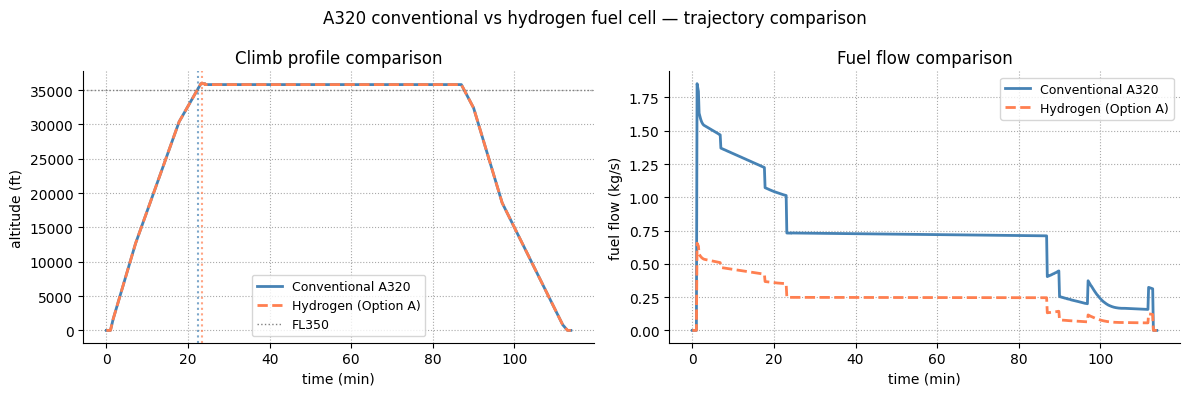

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot — altitude profiles
axes[0].plot(flight_conv.t / 60, flight_conv.altitude, 
             label='Conventional A320', color='steelblue', lw=2)
axes[0].plot(flight_h2.t / 60, flight_h2.altitude,
             label='Hydrogen (Option A)', color='coral', 
             lw=2, linestyle='--')
axes[0].axhline(y=35000, color='gray', linestyle=':', lw=1, label='FL350')
axes[0].axvline(x=t_cruise_conv/60, color='steelblue', 
                linestyle=':', lw=1.5, alpha=0.7)
axes[0].axvline(x=t_cruise_h2_B/60, color='coral', 
                linestyle=':', lw=1.5, alpha=0.7)
axes[0].set_xlabel("time (min)")
axes[0].set_ylabel("altitude (ft)")
axes[0].set_title("Climb profile comparison")
axes[0].legend(fontsize=9)
axes[0].grid(linestyle=":", color="darkgray")
axes[0].spines["right"].set_visible(False)
axes[0].spines["top"].set_visible(False)

# right plot — fuel flow comparison
axes[1].plot(flight_conv.t / 60, flight_conv.fuel_flow,
             label='Conventional A320', color='steelblue', lw=2)
axes[1].plot(flight_h2.t / 60, flight_h2.fuel_flow,
             label='Hydrogen (Option A)', color='coral', 
             lw=2, linestyle='--')
axes[1].set_xlabel("time (min)")
axes[1].set_ylabel("fuel flow (kg/s)")
axes[1].set_title("Fuel flow comparison")
axes[1].legend(fontsize=9)
axes[1].grid(linestyle=":", color="darkgray")
axes[1].spines["right"].set_visible(False)
axes[1].spines["top"].set_visible(False)

plt.suptitle("A320 conventional vs hydrogen fuel cell — trajectory comparison", 
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/03_mixed_fleet_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print(t_cruise_conv/60, t_cruise_h2_B/60)

22.333333333333332 23.50877192982456


---
# Module 3 — Mixed-Fleet Airspace Capacity Analysis

Using climb phase duration results from Module 2 to assess 
airspace capacity implications of mixed conventional/hydrogen 
fleet operations on the Amsterdam–London corridor.

**Research question:** How does increasing hydrogen aircraft penetration 
affect climb sector occupancy on a high-density European short-haul corridor?

**Key inputs:**
- Conventional A320 climb duration: 22.3 min
- Hydrogen aircraft climb duration (Option B): 23.5 min
- Extra climb time per hydrogen flight: 1.2 min (+5.3%)

In [18]:
import numpy as np
import pandas as pd

# inputs from Module 2
climb_conv = t_cruise_conv / 60
climb_h2_B = t_cruise_h2_B / 60
extra_climb = climb_h2_B - climb_conv

# Amsterdam-London corridor — approx 50 daily flights
daily_flights = 50

# hydrogen penetration scenarios 0% to 100%
penetration = np.arange(0, 101, 10)

# total extra sector occupancy per day
baseline_occupancy = daily_flights * climb_conv
extra_occupancy = (penetration / 100) * daily_flights * extra_climb
pct_increase = (extra_occupancy / baseline_occupancy) * 100

results = pd.DataFrame({
    'h2_penetration_%': penetration,
    'h2_flights_per_day': (penetration / 100 * daily_flights).astype(int),
    'extra_occupancy_min': extra_occupancy.round(1),
    'capacity_impact_%': pct_increase.round(2)
})

print(results.to_string(index=False))

 h2_penetration_%  h2_flights_per_day  extra_occupancy_min  capacity_impact_%
                0                   0                  0.0               0.00
               10                   5                  5.9               0.53
               20                  10                 11.8               1.05
               30                  15                 17.6               1.58
               40                  20                 23.5               2.11
               50                  25                 29.4               2.63
               60                  30                 35.3               3.16
               70                  35                 41.1               3.68
               80                  40                 47.0               4.21
               90                  45                 52.9               4.74
              100                  50                 58.8               5.26


## Section 5 — Mixed-Fleet Capacity Results

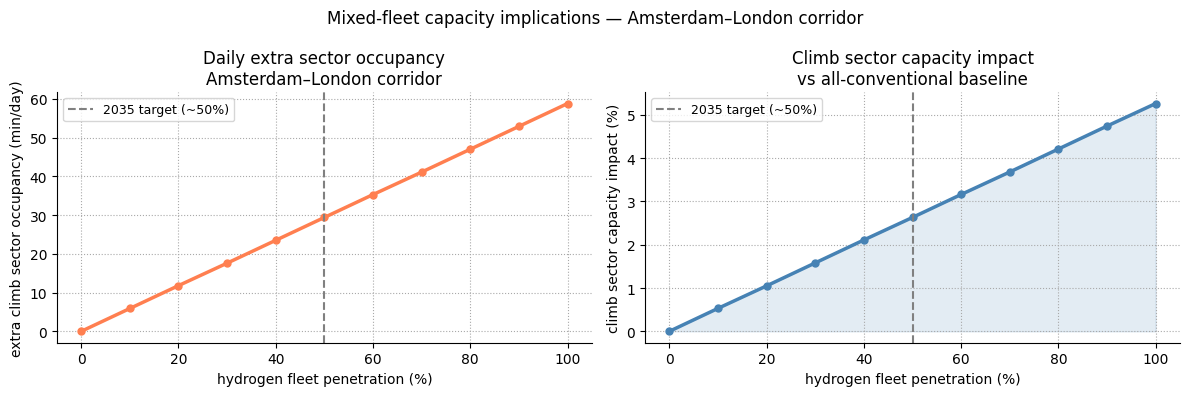

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# left — extra occupancy in minutes
ax1.plot(results['h2_penetration_%'], 
         results['extra_occupancy_min'],
         color='coral', lw=2.5, marker='o', markersize=5)
ax1.axvline(x=50, color='gray', linestyle='--', 
            lw=1.5, label='2035 target (~50%)')
ax1.set_xlabel("hydrogen fleet penetration (%)")
ax1.set_ylabel("extra climb sector occupancy (min/day)")
ax1.set_title("Daily extra sector occupancy\nAmsterdam–London corridor")
ax1.legend(fontsize=9)
ax1.grid(linestyle=":", color="darkgray")
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)

# right — capacity impact percentage
ax2.plot(results['h2_penetration_%'],
         results['capacity_impact_%'],
         color='steelblue', lw=2.5, marker='o', markersize=5)
ax2.axvline(x=50, color='gray', linestyle='--',
            lw=1.5, label='2035 target (~50%)')
ax2.fill_between(results['h2_penetration_%'],
                 results['capacity_impact_%'],
                 alpha=0.15, color='steelblue')
ax2.set_xlabel("hydrogen fleet penetration (%)")
ax2.set_ylabel("climb sector capacity impact (%)")
ax2.set_title("Climb sector capacity impact\nvs all-conventional baseline")
ax2.legend(fontsize=9)
ax2.grid(linestyle=":", color="darkgray")
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.suptitle("Mixed-fleet capacity implications — Amsterdam–London corridor",
             fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
print("t_cruise_conv" in dir())
print("t_cruise_h2_B" in dir())
print("flight_conv" in dir())
print("flight_h2" in dir())
print("LD_PENALTY" in dir())

True
True
True
True
True


In [21]:
cruise_alt = 35000
t_cruise_conv = flight_conv[flight_conv.altitude >= cruise_alt].t.min()
t_cruise_h2_A = flight_h2[flight_h2.altitude >= cruise_alt].t.min()
t_cruise_h2_B = t_cruise_h2_A / LD_PENALTY

print(f"t_cruise_conv: {t_cruise_conv/60:.1f} min")
print(f"t_cruise_h2_B: {t_cruise_h2_B/60:.1f} min")

t_cruise_conv: 22.3 min
t_cruise_h2_B: 23.5 min


In [26]:
import os
print(os.listdir('figures'))

['.ipynb_checkpoints', '01_baseline_trajectory.png', '02_trajectory_comparison.png', '03_mixed_fleet_capacity.png']
